In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from CoolProp.CoolProp import PropsSI
from IPython.display import display

## Funciones

In [2]:
def read_ANSYS(path):
    df = pd.read_csv(path, comment='#')
    legend = []
    with open(path, 'r') as f:
        for line in f:
            if line.startswith('# ,'):
                legend = line.strip('# ,\n').split(',')
    legend = {duple.split(' - ')[0]: duple.split(' - ')[1] for duple in legend}
    if 'index' in df.columns:
        df.drop('index', axis=1, inplace=True)
    return df.rename(legend, axis=1)

In [3]:
def get_SoH(row):
    r_eol = 0.12
    r_new = 0.032

    heats = []
    for c in list(row.index):
        if not pd.isna(row[c]) and c[0] == 'q':
            heats.append(row[c])
    heats = np.array(heats)
    arg_maxs = np.where(heats == heats.max())[0]

    if row['colIndex'] - 1 in arg_maxs:
        r = (heats.max() / heats.min()) * r_new
        row['SoH'] = (r_eol - r) / (r_eol - r_new)
    else:
        row['SoH'] = 1.0
    return row

In [4]:
def get_props(temperature, grades='K'):
    p_atm = 101325
    t = temperature - 273.15 if grades == 'C' else temperature

    rho_fun = np.vectorize(lambda T: PropsSI('D', 'T', T, 'P', p_atm, 'Air'))
    mu_fun  = np.vectorize(lambda T: PropsSI('V', 'T', T, 'P', p_atm, 'Air'))
    k_fun   = np.vectorize(lambda T: PropsSI('L', 'T', T, 'P', p_atm, 'Air'))
    pr_fun  = np.vectorize(lambda T: PropsSI("PRANDTL", "T", T, "P", p_atm, 'Air'))

    return pd.DataFrame({
        'rho': rho_fun(t),
        'mu' : mu_fun(t),
        'k'  : k_fun(t),
        'pr' : pr_fun(t),
    })

## Exportar Datos

In [5]:
folder = "./Data_ANSYS/df_ANSYS/"

paths = [
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if os.path.isfile(os.path.join(folder, f))
]

df_25 = []
df_53 = []
cols = None
for path in paths:
    if 'out25' in path:
        df_25.append(read_ANSYS(path).iloc[1: ])
    else:
        df = read_ANSYS(path)
        cols = df.columns if cols is None else cols
        df.columns = cols
        df_53.append(df.iloc[1: ])

df_25 = pd.concat(df_25, axis=0)
df_53 = pd.concat(df_53, axis=0)

print(paths)
display(df_25.head(2))
display(df_53.head(2))

['./Data_ANSYS/df_ANSYS/out25_soh45.csv', './Data_ANSYS/df_ANSYS/out25_soh45_1.csv', './Data_ANSYS/df_ANSYS/out25_soh62.csv', './Data_ANSYS/df_ANSYS/out25_soh82.csv', './Data_ANSYS/df_ANSYS/out53_soh45.csv', './Data_ANSYS/df_ANSYS/out53_soh62.csv', './Data_ANSYS/df_ANSYS/out53_soh82.csv']


,Name,R,x1,y1,nx,ny,dx,dy,L,H,...,Tf02 [K],Tf03 [K],Tf04 [K],Vf01 [m s^-1],Vf02 [m s^-1],Vf03 [m s^-1],Vf04 [m s^-1],Tc01 [K],Tc02 [K],Tc03 [K]
1,DP 1,9,25,20.00,4,4,41.5,40.00,174.5,160.00,...,294.466,294.858,295.793,0.557283,0.524121,0.496285,0.534792,304.341,299.110,299.112
2,DP 2,9,25,21.89,4,4,52.0,43.78,206.0,175.12,...,306.933,309.019,312.632,0.508186,0.502786,0.481961,0.496574,362.291,333.222,332.891


,Name,R,x1,y1,nx,ny,dx,dy,L,H,...,Vf06 [m s^-1],Vf07 [m s^-1],Vf08 [m s^-1],Tc01 [K],Tc02 [K],Tc03 [K],Tc04 [K],Tc05 [K],Tc06 [K],Tc07 [K]
1,DP 1,9,25,14.4,8,4,36.0,28.8,302.0,115.2,...,0.170732,0.174783,0.191198,317.355,311.244,317.528,324.943,332.159,339.240,346.186
2,DP 2,9,25,15.6,8,4,37.0,31.2,309.0,124.8,...,0.161579,0.156321,0.174405,366.343,347.845,361.466,377.403,393.261,409.507,426.112


## Cálculo de Nusselt

In [6]:
def get_nusselt(dataframe):
    df = dataframe.copy().reset_index(drop=True)

    Dc = 2 * df['R'] * 1e-3  # [mm] -> [m]
    Dh = 2 * (df['postdx'] * df['postdy']) / (df['postdx'] + df['postdy'])
    height = df['L'] * 1e-3
    surf = np.pi * Dc * height
    vol = height * np.pi * (Dc / 2) ** 2

    n_cols = sum([1 if c[: 2] == 'Tf' else 0 for c in df.columns])
    results = []

    for col in range(1, n_cols):

        # temperaturas
        tf_kelvin = (df[f"Tf0{col} [K]"] + df[f"Tf0{col + 1} [K]"]) / 2
        tf_celc = tf_kelvin - 273.15
        dT = df[f"Tc0{col} [K]"] - 273.15 - tf_celc  # en [C]

        # propiedades
        props = get_props(tf_kelvin, grades='K')
        rho, mu, k, pr = props['rho'], props['mu'], props['k'], props['pr']
        v = df[f"Vf0{col} [m s^-1]"]  # velocidad
        re = (rho * v * Dh) / mu  # reynolds

        # calcular h y nu
        q = df[f"q{col * 2} [W m^-3]" ] * vol
        q_surf = q / surf
        h = q_surf / (dT + 1e-9)
        nu = (h * Dh) / k

        # --- 9. Ensamblar datos para esta columna ---
        df_temp = pd.DataFrame({
            'S': df['postdy'] / Dc,
            'colIndex': col,
            'Re': re,
            'Nu': nu,
            'Pr': pr
        })
        for col in range(1, n_cols): df_temp[f'q{col}'] = df[f"q{2 * col} [W m^-3]"]

        results.append(df_temp)

    return pd.concat(results, ignore_index=True).apply(get_SoH, axis=1)

### 25 Celdas

In [7]:
nu_25 = get_nusselt(df_25.dropna())
nu_25 = nu_25[(0 < nu_25['Nu']) & (nu_25['Nu'] < 200)]
nu_25.head()

,S,colIndex,Re,Nu,Pr,q1,q2,q3,SoH
0,2.222222,1.0,1498.798470,40.943435,0.707909,62682.615150,25073.0461,25073.0461,0.454545
1,2.432222,1.0,1521.212817,49.673561,0.706887,374547.972000,149819.1888,149819.1888,0.454545
2,1.920000,1.0,2137.234139,38.281796,0.708099,6964.735016,2785.8400,2785.8400,0.454528
3,2.258889,1.0,1762.253606,44.185059,0.708026,30228.884620,12091.5538,12091.5538,0.454545
4,2.031111,1.0,1863.743152,38.665032,0.708073,15670.653800,6268.2615,6268.2615,0.454545


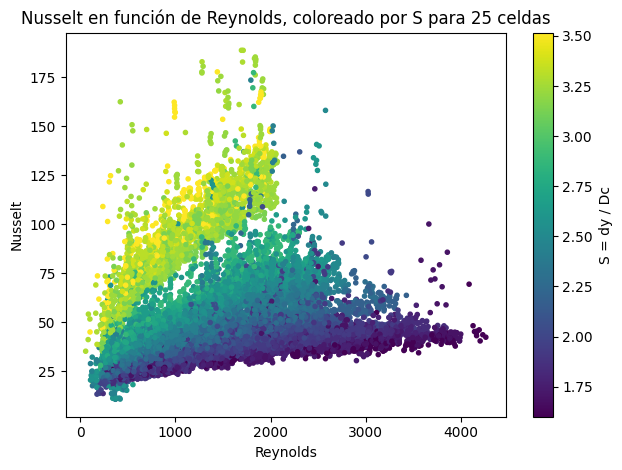

In [8]:
plt.scatter(nu_25['Re'], nu_25['Nu'], marker='.', c=nu_25['S'], cmap='viridis')
plt.colorbar(label='S = dy / Dc')
plt.ylabel("Nusselt")
plt.xlabel('Reynolds')
plt.title('Nusselt en función de Reynolds, coloreado por S para 25 celdas')
plt.tight_layout()
plt.show()

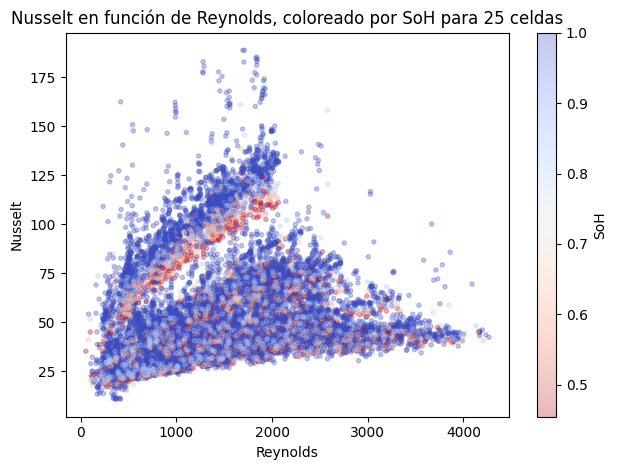

In [9]:
plt.scatter(nu_25['Re'], nu_25['Nu'], marker='.', c=nu_25['SoH'], cmap='coolwarm_r', alpha=0.3)
plt.colorbar(label='SoH')
plt.ylabel("Nusselt")
plt.xlabel('Reynolds')
plt.title('Nusselt en función de Reynolds, coloreado por SoH para 25 celdas')
plt.tight_layout()
plt.show()

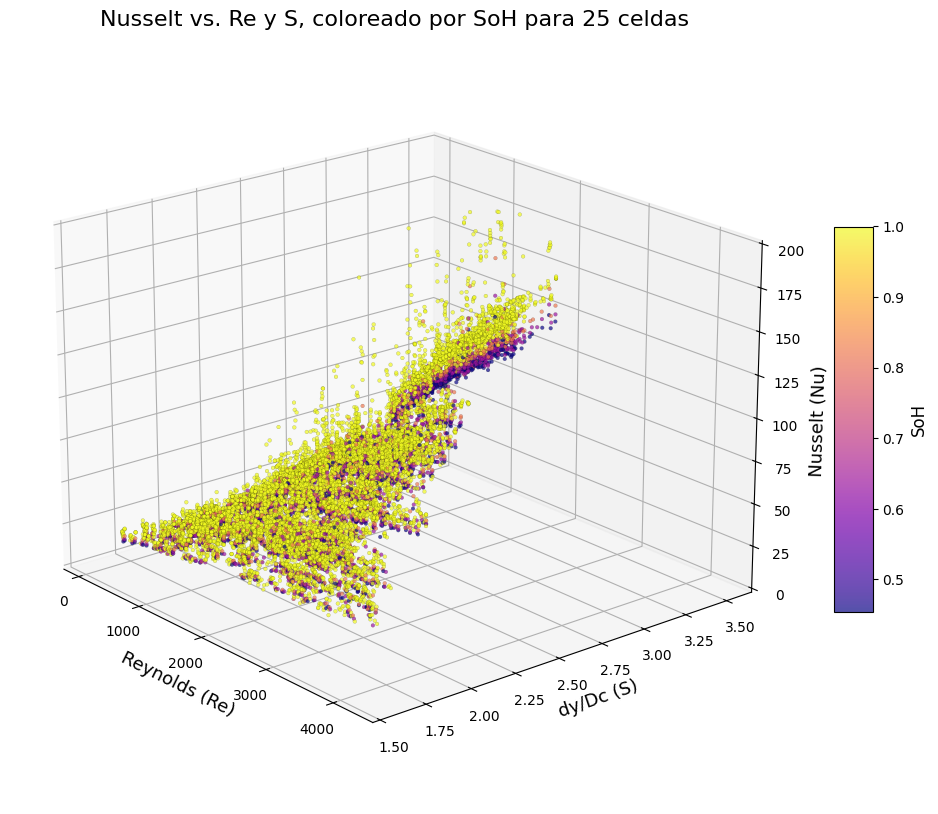

In [38]:
x = nu_25['Re']
y = nu_25['S']
z = nu_25['Nu']

# --- 2. Crear la figura y el eje 3D ---
fig = plt.figure(figsize=(14, 10)) # Un poco más grande
ax = fig.add_subplot(111, projection='3d')

# --- 3. Dibujar el Scatter 3D ---
sc = ax.scatter(
    x, y, z,
    c=nu_25['SoH'],
    cmap='plasma',
    s=30,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.1,
    marker='.'
)

ax.set_xlabel('Reynolds (Re)', fontsize=13)
ax.set_ylabel('dy/Dc (S)', fontsize=13)
ax.set_zlabel('Nusselt (Nu)', fontsize=13)
ax.set_title('Nusselt vs. Re y S, coloreado por SoH para 25 celdas', fontsize=16)

cbar = fig.colorbar(sc, shrink=0.5, aspect=10)
cbar.set_label('SoH', fontsize=12)

ax.view_init(elev=20, azim=-40)
ax.dist = 10

plt.show()

### 53 Celdas

In [11]:
nu_53 = get_nusselt(df_53.dropna())
nu_53 = nu_53[(0 < nu_53['Nu']) & (nu_53['Nu'] < 200)]
nu_53.head()

,S,colIndex,Re,Nu,Pr,q1,q2,q3,q4,q5,q6,q7,SoH
0,1.600000,1.0,364.458283,21.150256,0.708019,93636.992999,37454.7972,37454.7972,37454.7972,37454.7972,37454.7972,37454.7972,0.454545
1,1.733333,1.0,349.308602,20.770724,0.706436,223645.380000,89458.1520,89458.1520,89458.1520,89458.1520,89458.1520,89458.1520,0.454545
2,1.889333,1.0,335.812605,20.996446,0.708779,43529.593850,17411.8375,17411.8375,17411.8375,17411.8375,17411.8375,17411.8375,0.454545
3,1.696667,1.0,443.931856,20.814365,0.708945,32695.561610,13078.2246,13078.2246,13078.2246,13078.2246,13078.2246,13078.2246,0.454545
4,1.774444,1.0,482.038990,21.377232,0.709227,10882.398460,4352.9594,4352.9594,4352.9594,4352.9594,4352.9594,4352.9594,0.454545


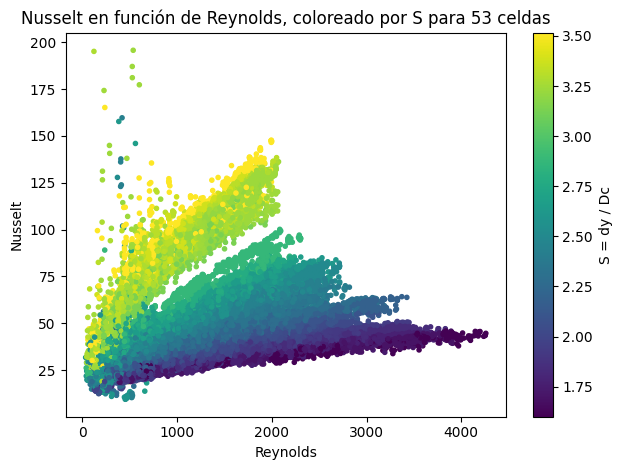

In [12]:
plt.scatter(nu_53['Re'], nu_53['Nu'], marker='.', c=nu_53['S'], cmap='viridis')
plt.colorbar(label='S = dy / Dc')
plt.ylabel("Nusselt")
plt.xlabel('Reynolds')
plt.title('Nusselt en función de Reynolds, coloreado por S para 53 celdas')
plt.tight_layout()
plt.show()

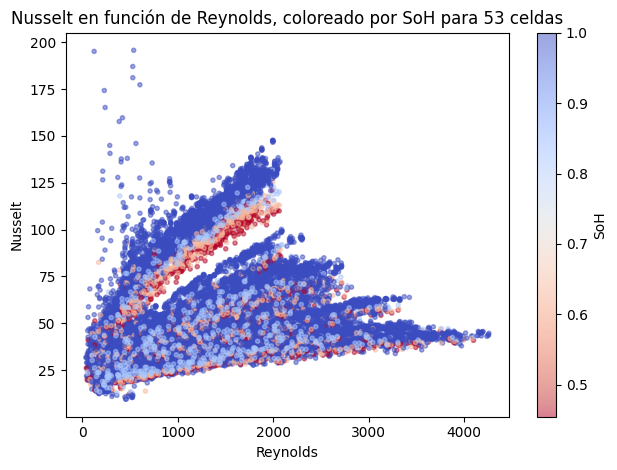

In [13]:
plt.scatter(nu_53['Re'], nu_53['Nu'], marker='.', c=nu_53['SoH'], cmap='coolwarm_r', alpha=0.5)
plt.colorbar(label='SoH')
plt.ylabel("Nusselt")
plt.xlabel('Reynolds')
plt.title('Nusselt en función de Reynolds, coloreado por SoH para 53 celdas')
plt.tight_layout()
plt.show()

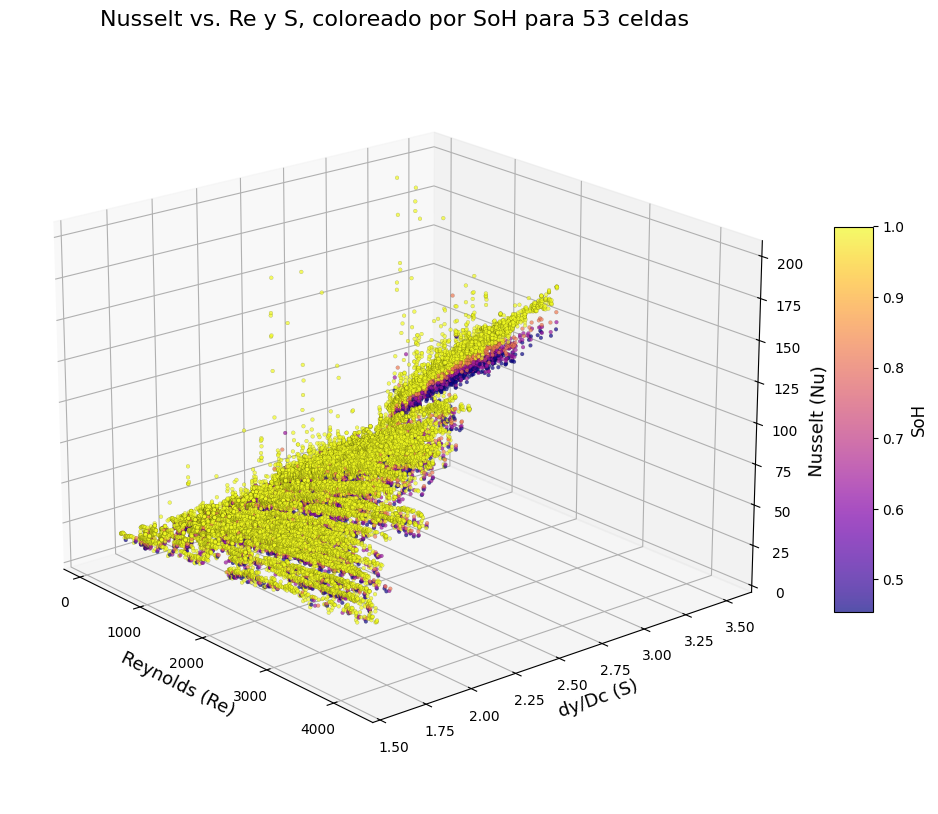

In [39]:
x = nu_53['Re']
y = nu_53['S']
z = nu_53['Nu']

# --- 2. Crear la figura y el eje 3D ---
fig = plt.figure(figsize=(14, 10)) # Un poco más grande
ax = fig.add_subplot(111, projection='3d')

# --- 3. Dibujar el Scatter 3D ---
sc = ax.scatter(
    x, y, z,
    c=nu_53['SoH'],
    cmap='plasma',
    s=30,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.1,
    marker='.'
)

ax.set_xlabel('Reynolds (Re)', fontsize=13)
ax.set_ylabel('dy/Dc (S)', fontsize=13)
ax.set_zlabel('Nusselt (Nu)', fontsize=13)
ax.set_title('Nusselt vs. Re y S, coloreado por SoH para 53 celdas', fontsize=16)

cbar = fig.colorbar(sc, shrink=0.5, aspect=10)
cbar.set_label('SoH', fontsize=12)

ax.view_init(elev=20, azim=-40)
ax.dist = 10

plt.show()

## Exportación del archivo

In [14]:
nu_25.to_csv('nu_25.csv', index=False)
nu_53.to_csv('nu_53.csv', index=False)

In [16]:
ex25 = pd.read_csv('nu_25.csv')
ex53 = pd.read_csv('nu_53.csv')

display(ex25.iloc[-2: ])
display(ex53.iloc[-2: ])

,S,colIndex,Re,Nu,Pr,q1,q2,q3,SoH
17537,2.258889,3.0,1445.256744,40.414528,0.706509,12091.5538,12091.5538,18137.330772,0.818182
17538,2.504444,3.0,2023.919429,68.616070,0.706619,6268.2615,6268.2615,9402.392300,0.818182


,S,colIndex,Re,Nu,Pr,q1,q2,q3,q4,q5,q6,q7,SoH
34965,2.258889,7.0,1274.618817,37.820353,0.706295,12091.5538,12091.5538,12091.5538,12091.5538,12091.5538,18137.330772,18137.330772,0.818182
34966,2.504444,7.0,1808.167126,66.594654,0.706545,6268.2615,6268.2615,6268.2615,6268.2615,6268.2615,9402.392300,9402.392300,0.818182
